# Chapter 9: System Archetypes as Hypothesis Templates

*Systems Thinking with AI* by Jason Karpeles

A template accepts almost any situation; the boundary and the observation decide what it predicts.

**Goal.** Four small experiments on limits to growth, built from the chapter's own engine. See how little an early limit costs per step, how moving the boundary inside the model reverses the outcome, how the length of a record decides whether it can separate two accounts, and how one parameter set to zero turns one model into the other.

**Demonstrations**

1. An early limit is easy to dismiss
2. Same engine, two boundaries
3. The window decides what the record can show
4. One parameter turns B into A

The chapter's own model code is written out in full below, so the notebook runs with NumPy and Matplotlib alone. The interactive version of this chapter is at [https://karpeles.com/companions/systems-thinking-with-ai/09-archetypes/reader.html](https://karpeles.com/companions/systems-thinking-with-ai/09-archetypes/reader.html).

All example inputs are constructed teaching examples built from the chapter's own numbers.

## Setup

Imports, plus two small helpers: `%%module` runs a cell as a named module so the chapter files can import one another by their package names, and `show` draws a demonstration's figure and lists its values.

In [1]:
import os, sys, tempfile, types
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from IPython.core.magic import register_cell_magic
from IPython.display import Markdown, display

%matplotlib inline

WORKDIR = tempfile.mkdtemp(prefix="systems-thinking-")


@register_cell_magic
def module(line, cell):
    """Run a cell as a named module so the chapter code can import it by name."""
    name = line.strip()
    parts = name.split(".")
    for i in range(1, len(parts)):
        parent = ".".join(parts[:i])
        if parent not in sys.modules:
            pkg = types.ModuleType(parent)
            pkg.__path__ = []
            sys.modules[parent] = pkg
            if i > 1:
                setattr(sys.modules[".".join(parts[:i - 1])], parts[i - 1], pkg)
    mod = types.ModuleType(name)
    mod.__file__ = os.path.join(WORKDIR, *parts) + ".py"
    mod.__package__ = ".".join(parts[:-1])
    sys.modules[name] = mod
    if len(parts) > 1:
        setattr(sys.modules[".".join(parts[:-1])], parts[-1], mod)
    exec(compile(cell, name, "exec"), mod.__dict__)


def show(result):
    """Draw the figure, then list the calculated values and the reading."""
    fig, metrics, interpretation = result[:3]
    plt.show()
    display(Markdown("\n".join(f"- **{k}:** {v}" for k, v in metrics.items())))
    display(Markdown(interpretation))


def sweep(function, controls):
    """Recompute every setting offered in the interactive reader and list the values."""
    import itertools
    keys = [k for k, _ in controls]
    rows = []
    for combo in itertools.product(*[v for _, v in controls]):
        fig, metrics, _ = function(**dict(zip(keys, combo)))[:3]
        plt.close(fig)
        setting = ", ".join(f"{k} = {v}" for k, v in zip(keys, combo))
        rows.append(f"- **{setting}**: " + "; ".join(f"{k} {v}" for k, v in metrics.items()))
    display(Markdown("\n".join(rows)))


## The chapter's model code

Each cell below is one file of the chapter's code, defined under its package name. Later chapters build on earlier ones, so some files come from the chapters they cite.

`chapters/chapter_09_archetypes/code/validate_number.py`

In [2]:
%%module chapters.chapter_09_archetypes.code.validate_number
import math


def validate_number(value: float, name: str) -> None:
    """Reject non-numeric or non-finite values used by the teaching functions."""
    if type(value) not in (int, float) or not math.isfinite(float(value)):
        raise ValueError(f"{name} must be a finite number")


`chapters/chapter_09_archetypes/code/limits.py`

In [3]:
%%module chapters.chapter_09_archetypes.code.limits
"""Limits to growth, implemented twice with different boundaries.

Same archetype, same growth engine, one difference: whether the limit is outside
the model or inside it. The behaviors are not variations on each other.
"""

from .validate_number import validate_number


def _check(initial: float, capacity: float, rate: float, steps: int) -> None:
    for value, name in ((initial, "initial"), (capacity, "capacity"), (rate, "rate")):
        validate_number(value, name)
    if capacity <= 0:
        raise ValueError("capacity must be positive")
    if type(steps) is not int or steps < 1:
        raise ValueError("steps must be a positive integer")


def fixed_limit(
    initial: float, capacity: float, rate: float, steps: int, dt: float = 1.0
) -> list[float]:
    """Boundary A: the limit is exogenous. Growth approaches it and stops."""
    _check(initial, capacity, rate, steps)
    path = [float(initial)]
    for _ in range(steps):
        state = path[-1]
        path.append(state + dt * rate * state * (1.0 - state / capacity))
    return path


def eroding_limit(
    initial: float,
    capacity: float,
    rate: float,
    erosion_rate: float,
    steps: int,
    dt: float = 1.0,
) -> tuple[list[float], list[float]]:
    """Boundary B: the limit is endogenous, consumed by the growth it constrains.

    Returns the state path and the capacity path, because under this boundary the
    capacity is a model variable and hiding it would hide the mechanism.
    """
    _check(initial, capacity, rate, steps)
    validate_number(erosion_rate, "erosion_rate")
    if erosion_rate < 0:
        raise ValueError("erosion_rate must be non-negative")
    state_path, capacity_path = [float(initial)], [float(capacity)]
    for _ in range(steps):
        state, limit = state_path[-1], capacity_path[-1]
        growth = rate * state * (1.0 - state / limit) if limit > 0 else -rate * state
        capacity_path.append(max(0.0, limit - dt * erosion_rate * state))
        state_path.append(max(0.0, state + dt * growth))
    return state_path, capacity_path


def settles(path: list[float], tolerance: float = 0.01) -> bool:
    """True when the path stops moving. The observable that separates the two boundaries."""
    if len(path) < 3:
        raise ValueError("path is too short to judge")
    return abs(path[-1] - path[-2]) < tolerance and path[-1] > tolerance


def peaks_then_falls(path: list[float], margin: float = 0.05) -> bool:
    """True when the path rises to a peak and ends meaningfully below it."""
    peak = max(path)
    return peak > path[0] and path[-1] < peak * (1.0 - margin)


Formatting and plotting helpers used by the demonstrations (`readerkit`).

In [4]:
%%module readerkit
"""Formatting and plotting helpers shared by the demonstrations."""
from __future__ import annotations

import math

# Restrained palette with good contrast on white. Use direct labels, not
# colour alone, to distinguish series.
PALETTE = {
    "ink": "#172a3b",
    "teal": "#136f75",
    "gold": "#8f5d0f",
    "navy": "#334c72",
    "terracotta": "#a24a33",
    "olive": "#5d6a37",
    "grey": "#6b757b",
    "light": "#c9d3d6",
}

FONT_SIZE = 11.5
SMALL_FONT = 10.5


def new_figure(ncols=1, width=None, height=4.3):
    """Return (fig, axes) with constrained layout and the house size.

    One panel is 6.6 x 4.3 inches; two panels are 10.4 x 4.3 inches. At the
    reader's display width this keeps 11 to 12 point text legible.
    """
    import matplotlib.pyplot as plt

    if width is None:
        width = 6.6 if ncols == 1 else 10.4
    fig, axes = plt.subplots(1, ncols, figsize=(width, height), layout="constrained")
    for ax in (axes if ncols > 1 else [axes]):
        ax.grid(alpha=0.18)
    return fig, axes


def fmt(value, digits=2):
    """Format a finite number with a fixed number of decimals.

    Returns the string "undefined" for None. Raises ValueError for NaN or
    infinity, because a reader must be told why a value is undefined; use
    ``undefined(reason)`` for that.
    """
    if value is None:
        return "undefined"
    value = float(value)
    if not math.isfinite(value):
        raise ValueError("non-finite value; state why it is undefined with undefined(reason)")
    text = f"{value:.{digits}f}"
    if text.startswith("-") and float(text) == 0:
        text = text[1:]
    return text


def signed(value, digits=2):
    """Format a number for use inside a written calculation: negatives get parentheses."""
    text = fmt(value, digits)
    return f"({text})" if text.startswith("-") else text


def undefined(reason):
    """Display string for a quantity that has no value in this state."""
    return f"undefined ({reason})"


def is_tie(a, b, tol=1e-9):
    return abs(float(a) - float(b)) <= tol


def argmax_set(scores, tol=1e-9):
    """Names whose score is within tol of the maximum. ``scores`` is a dict."""
    best = max(scores.values())
    return [name for name, value in scores.items() if abs(value - best) <= tol]


def label_point(ax, x, y, text, color=None, dx=6, dy=6, ha="left", va="bottom", size=None):
    """Directly label a point with an offset in points (no arrow)."""
    return ax.annotate(
        text,
        (x, y),
        xytext=(dx, dy),
        textcoords="offset points",
        ha=ha,
        va=va,
        color=color or PALETTE["ink"],
        fontsize=size or SMALL_FONT,
    )


## Demonstration functions

Each function below runs the chapter's model for one demonstration and returns a figure, the calculated values and a worked reading of them.

In [5]:
"""Chapter 9 reader: archetypes as hypothesis templates, and the boundary that decides the behavior.

Every path comes from the Chapter 9 pack (fixed_limit, eroding_limit, settles,
peaks_then_falls) so the reader, the pack and the book agree.
"""
from __future__ import annotations

import numpy as np
from readerkit import PALETTE, fmt, label_point, new_figure, signed

from chapters.chapter_09_archetypes.code.limits import (
    eroding_limit,
    fixed_limit,
    peaks_then_falls,
    settles,
)

EQ_FIXED = "a = fixed_limit(initial=1.0, capacity=100.0, rate=0.3, steps=120)"
EQ_A = "max(a), a[-1]"
EQ_B = "max(b), b[-1], capacity[-1]"
EQ_EROSION = "erosion_rate"

CAPACITY = 100.0


# Demonstration 1: the limit multiplier at a given load.

def limit_multiplier(load_share=0.02, rate=0.3):
    state = load_share * CAPACITY
    path = fixed_limit(state, CAPACITY, rate, 1)
    actual = path[1] - path[0]
    free = rate * state
    multiplier = actual / free

    fig, (left, right) = new_figure(ncols=2)
    xs = np.linspace(0, 1, 51)
    left.plot(xs, 1 - xs, color=PALETTE["navy"])
    left.plot([load_share], [multiplier], marker="o", markersize=9, color=PALETTE["terracotta"])
    label_point(left, load_share, multiplier, f"{fmt(multiplier, 2)} at {fmt(load_share * 100, 0)}%",
                color=PALETTE["terracotta"], dx=(-10 if load_share > 0.5 else 10), dy=8,
                ha=("right" if load_share > 0.5 else "left"))
    left.set_xlim(0, 1.0)
    left.set_ylim(0, 1.1)
    left.set_xlabel("Load as a share of capacity")
    left.set_ylabel("Share of unconstrained growth")
    left.set_title("The limit multiplier", fontsize=11.5)

    bars = right.bar([0, 1], [free, actual], color=[PALETTE["light"], PALETTE["teal"]], width=0.55)
    for x, v in zip([0, 1], [free, actual]):
        right.annotate(fmt(v, 2), (x, v), xytext=(0, 4), textcoords="offset points", ha="center",
                       fontsize=10.5)
    right.set_xticks([0, 1], ["No limit", "With limit"])
    right.set_ylim(0, max(free, 1.0) * 1.25)
    right.set_xlabel("Growth in one step")
    right.set_ylabel("Units added per step")
    right.set_title("What one step adds", fontsize=11.5)

    metrics = {
        "Load (units of 100)": fmt(state, 1),
        "Share of unconstrained rate": fmt(multiplier, 2),
        "Growth with no limit (per step)": fmt(free, 2),
        "Growth with the limit (per step)": fmt(actual, 2),
        "Shortfall (per step)": fmt(free - actual, 2),
    }
    interpretation = (
        f"Multiplier = 1 - {fmt(state, 1)} / 100 = {fmt(multiplier, 2)}. With no limit one step adds "
        f"{fmt(rate, 1)} x {fmt(state, 1)} = {fmt(free, 2)}; with the limit it adds {fmt(free, 2)} x "
        f"{fmt(multiplier, 2)} = {fmt(actual, 2)}. The shortfall is {fmt(free - actual, 2)} per step, "
        f"{fmt((1 - multiplier) * 100, 0)}% of the unconstrained growth."
    )
    return fig, metrics, interpretation


# Demonstration 2: one engine, two boundaries.

def two_boundaries(rate=0.4, horizon=200):
    a = fixed_limit(1.0, CAPACITY, rate, horizon)
    b, cap = eroding_limit(1.0, CAPACITY, rate, 0.02, horizon)
    t = np.arange(horizon + 1)

    fig, ax = new_figure()
    ax.plot(t, a, color=PALETTE["navy"])
    ax.plot(t, b, color=PALETTE["teal"])
    ax.plot(t, cap, color=PALETTE["terracotta"], linestyle="dashed")
    ax.set_xlim(0, horizon)
    ax.set_ylim(0, 112)
    label_point(ax, horizon, a[-1], "A: fixed limit", color=PALETTE["navy"], dx=-4, dy=-4, ha="right", va="top")
    peak_i = int(np.argmax(b))
    mid = int(0.55 * horizon)
    label_point(ax, mid, b[mid], "B: eroding limit", color=PALETTE["teal"], dx=8, dy=8)
    label_point(ax, horizon, cap[-1], "B's capacity", color=PALETTE["terracotta"], dx=-4, dy=12, ha="right")
    ax.set_xlabel("Step")
    ax.set_ylabel("State and capacity")

    metrics = {
        "A: value at the end": fmt(a[-1], 1),
        "B: peak": fmt(max(b), 1),
        "B: step of the peak": peak_i,
        "B: value at the end": fmt(b[-1], 1),
        "B: capacity at the end": fmt(cap[-1], 1),
    }
    first = 1.0 + rate * 1.0 * (1 - 1.0 / CAPACITY)
    interpretation = (
        f"Both start with 1 + {fmt(rate, 1)} x 1 x (1 - 1 / 100) = {fmt(first, 3)} after one step. Then B's "
        f"capacity falls by 0.02 x state each step: 100 - 0.02 x 1 = {fmt(100 - 0.02, 2)}. After {horizon} "
        f"steps A is at {fmt(a[-1], 1)}, while B peaked at {fmt(max(b), 1)} (step {peak_i}), ended at "
        f"{fmt(b[-1], 1)}, and left a capacity of {fmt(cap[-1], 1)}."
    )
    return fig, metrics, interpretation


# Demonstration 3: the reading depends on the window.

def window_reading(erosion=0.02, window=60):
    b, _ = eroding_limit(1.0, CAPACITY, 0.4, erosion, window)
    peak = max(b)
    threshold = peak * 0.95
    falls = peaks_then_falls(b)
    still = settles(b)
    t = np.arange(window + 1)

    fig, ax = new_figure()
    ax.plot(t, b, color=PALETTE["teal"])
    ax.axhline(threshold, color=PALETTE["grey"], linestyle="dashed", linewidth=1.4)
    ax.plot([int(np.argmax(b))], [peak], marker="o", markersize=8, color=PALETTE["navy"])
    ax.plot([window], [b[-1]], marker="s", markersize=8, color=PALETTE["terracotta"])
    ax.set_xlim(0, window * 1.02)
    ax.set_ylim(0, 112)
    label_point(ax, window, threshold, "95% of peak", color=PALETTE["grey"], dx=-4, dy=5, ha="right")
    label_point(ax, int(np.argmax(b)), peak, f"peak {fmt(peak, 1)}", color=PALETTE["navy"], dx=8, dy=6)
    label_point(ax, window, b[-1], f"end {fmt(b[-1], 1)}", color=PALETTE["terracotta"], dx=-6, dy=(10 if b[-1] < 25 else -10),
                ha="right", va=("bottom" if b[-1] < 25 else "top"))
    ax.set_xlabel("Step (the length of the record)")
    ax.set_ylabel("State")

    if falls:
        verdict = "Peaks then falls: the end is more than 5% below the peak, so the record separates B from A."
    elif still:
        verdict = "Settles: the last step moves by less than 0.01."
    else:
        verdict = ("Neither test fires: the end is within 5% of the peak and the last step still moves, "
                   "so this record cannot yet tell B from a slowed growth.")
    metrics = {
        "Peak": fmt(peak, 1),
        "End of record": fmt(b[-1], 1),
        "95% of peak": fmt(threshold, 1),
        "Last step change": signed(b[-1] - b[-2], 2),
        "Settles": "yes" if still else "no",
        "Peaks then falls": "yes" if falls else "no",
    }
    interpretation = (
        f"Threshold = 0.95 x {fmt(peak, 1)} = {fmt(threshold, 1)}. The record ends at {fmt(b[-1], 1)}, "
        f"{'below' if b[-1] < threshold else 'not below'} it. Last step change = {fmt(b[-1], 2)} - "
        f"{fmt(b[-2], 2)} = {signed(b[-1] - b[-2], 2)}. {verdict}"
    )
    return fig, metrics, interpretation


# Demonstration 4: erosion zero collapses B into A.

def zero_erosion(erosion_rate=0.0, rate=0.4):
    horizon = 200
    a = fixed_limit(1.0, CAPACITY, rate, horizon)
    b, cap = eroding_limit(1.0, CAPACITY, rate, erosion_rate, horizon)
    gap = max(abs(x - y) for x, y in zip(a, b))
    t = np.arange(horizon + 1)

    fig, (left, right) = new_figure(ncols=2)
    left.plot(t, a, color=PALETTE["grey"], linestyle="dashed", linewidth=2.2)
    left.plot(t, b, color=PALETTE["teal"])
    left.set_xlim(0, horizon)
    left.set_ylim(0, 112)
    label_point(left, 60, 100, "A (dashed)", color=PALETTE["grey"], dx=0, dy=6, ha="left")
    label_point(left, horizon, b[-1], "B", color=PALETTE["teal"], dx=-4, dy=8, ha="right")
    left.set_xlabel("Step")
    left.set_ylabel("State")
    left.set_title("A and B", fontsize=11.5)
    right.plot(t, cap, color=PALETTE["terracotta"])
    right.set_xlim(0, horizon)
    right.set_ylim(0, 112)
    label_point(right, horizon, cap[-1], f"{fmt(cap[-1], 1)}", color=PALETTE["terracotta"], dx=-4, dy=8, ha="right")
    right.set_xlabel("Step")
    right.set_ylabel("B's capacity")
    right.set_title("B's capacity", fontsize=11.5)

    identical = gap < 1e-9
    metrics = {
        "Erosion rate": fmt(erosion_rate, 3),
        "Largest gap between B and A": fmt(gap, 2),
        "B: value at the end": fmt(b[-1], 1),
        "B: capacity at the end": fmt(cap[-1], 1),
        "Same path as A": "yes (tie)" if identical else "no",
    }
    tail = ("The two paths are the same, so B has become A." if identical
            else "The only change from A is the erosion rate, and it opens a gap.")
    interpretation = (
        f"After the first step the capacity is 100 - {fmt(erosion_rate, 3)} x 1 = "
        f"{fmt(100 - erosion_rate, 3)}. Over {horizon} steps the largest gap between B and A is "
        f"{fmt(gap, 2)} units and B ends at {fmt(b[-1], 1)} against A's {fmt(a[-1], 1)}. {tail}"
    )
    return fig, metrics, interpretation


## 1. An early limit is easy to dismiss

*How much of the unconstrained growth is a limit already taking away at low load?*

The chapter's logistic step adds rate x state x (1 - state / capacity). Dividing by the unconstrained growth, rate x state, leaves 1 - state / capacity, a straight line from 1 at no load to 0 at full capacity.

    a = fixed_limit(initial=1.0, capacity=100.0, rate=0.3, steps=120)

**Symbols and inputs.** load is the state as a share of the capacity of 100. rate is the unconstrained growth rate per step. The multiplier 1 - load / capacity is the share of the unconstrained growth that remains.

**Predict first.** At 10% of capacity, what share of the unconstrained growth is left?

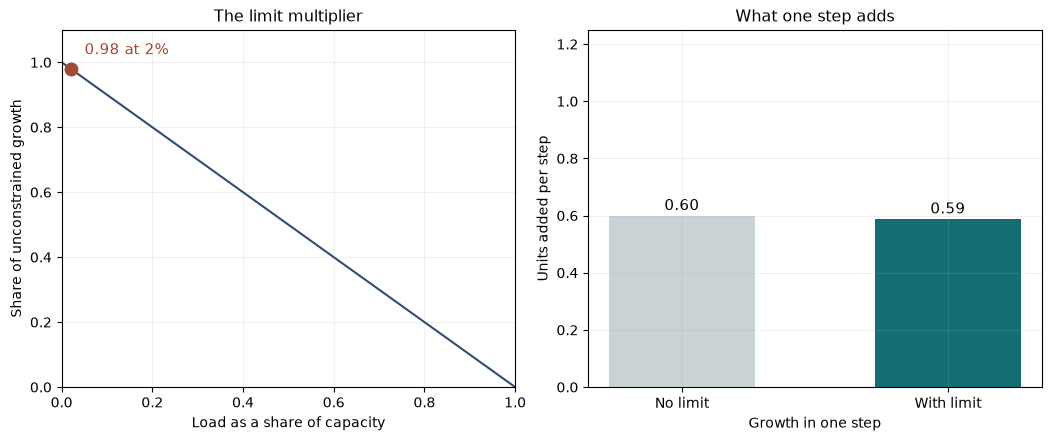

- **Load (units of 100):** 2.0
- **Share of unconstrained rate:** 0.98
- **Growth with no limit (per step):** 0.60
- **Growth with the limit (per step):** 0.59
- **Shortfall (per step):** 0.01

Multiplier = 1 - 2.0 / 100 = 0.98. With no limit one step adds 0.3 x 2.0 = 0.60; with the limit it adds 0.60 x 0.98 = 0.59. The shortfall is 0.01 per step, 2% of the unconstrained growth.

In [6]:
show(limit_multiplier(load_share=0.02, rate=0.3))

**Use the idea.** A modest shortfall at low load is exactly the size that reads as noise, so name the limit before it is measurable.

**Where the conclusion applies.** A capacity of 100 held fixed and one step of dt = 1. The logistic form assumes the shortfall is linear in load; a limit that bites only near the top would not look like this.

*Constructed example: the chapter's logistic engine with load shares and rates chosen for this reader.*

Every setting the interactive reader offers for this demonstration:

In [7]:
sweep(limit_multiplier, [('load_share', [0.02, 0.1, 0.5, 0.9]), ('rate', [0.3, 0.4])])

- **load_share = 0.02, rate = 0.3**: Load (units of 100) 2.0; Share of unconstrained rate 0.98; Growth with no limit (per step) 0.60; Growth with the limit (per step) 0.59; Shortfall (per step) 0.01
- **load_share = 0.02, rate = 0.4**: Load (units of 100) 2.0; Share of unconstrained rate 0.98; Growth with no limit (per step) 0.80; Growth with the limit (per step) 0.78; Shortfall (per step) 0.02
- **load_share = 0.1, rate = 0.3**: Load (units of 100) 10.0; Share of unconstrained rate 0.90; Growth with no limit (per step) 3.00; Growth with the limit (per step) 2.70; Shortfall (per step) 0.30
- **load_share = 0.1, rate = 0.4**: Load (units of 100) 10.0; Share of unconstrained rate 0.90; Growth with no limit (per step) 4.00; Growth with the limit (per step) 3.60; Shortfall (per step) 0.40
- **load_share = 0.5, rate = 0.3**: Load (units of 100) 50.0; Share of unconstrained rate 0.50; Growth with no limit (per step) 15.00; Growth with the limit (per step) 7.50; Shortfall (per step) 7.50
- **load_share = 0.5, rate = 0.4**: Load (units of 100) 50.0; Share of unconstrained rate 0.50; Growth with no limit (per step) 20.00; Growth with the limit (per step) 10.00; Shortfall (per step) 10.00
- **load_share = 0.9, rate = 0.3**: Load (units of 100) 90.0; Share of unconstrained rate 0.10; Growth with no limit (per step) 27.00; Growth with the limit (per step) 2.70; Shortfall (per step) 24.30
- **load_share = 0.9, rate = 0.4**: Load (units of 100) 90.0; Share of unconstrained rate 0.10; Growth with no limit (per step) 36.00; Growth with the limit (per step) 3.60; Shortfall (per step) 32.40

## 2. Same engine, two boundaries

*If the limit sits outside the model, then inside it, do the two runs agree?*

A approaches its fixed ceiling and stays. In B the growing state consumes the capacity that supports it, so growth stalls, then the state follows the shrinking capacity down.

    max(a), a[-1]
    max(b), b[-1], capacity[-1]

**Symbols and inputs.** A holds capacity at 100. B starts at 100 and loses 0.02 x state of capacity each step. Both start at 1 and use the same growth rate.

**Predict first.** With rate 0.4 over 200 steps, does B end higher or lower than A?

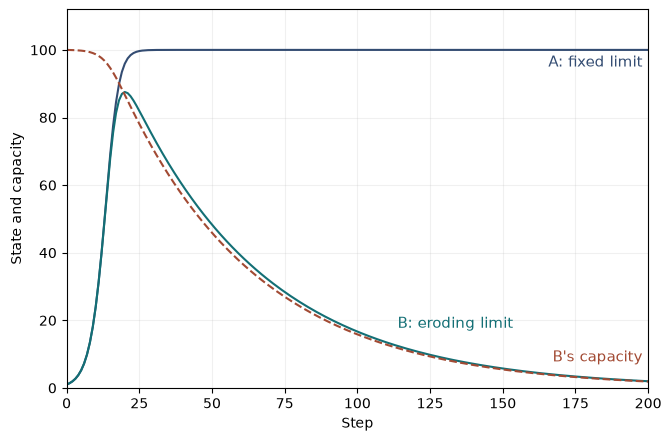

- **A: value at the end:** 100.0
- **B: peak:** 87.6
- **B: step of the peak:** 20
- **B: value at the end:** 2.0
- **B: capacity at the end:** 1.9

Both start with 1 + 0.4 x 1 x (1 - 1 / 100) = 1.396 after one step. Then B's capacity falls by 0.02 x state each step: 100 - 0.02 x 1 = 99.98. After 200 steps A is at 100.0, while B peaked at 87.6 (step 20), ended at 2.0, and left a capacity of 1.9.

In [8]:
show(two_boundaries(rate=0.4, horizon=200))

**Use the idea.** Before accepting an archetype name, ask whether the limit is a fixed property of the environment or something the growth consumes.

**Where the conclusion applies.** One erosion rate, 0.02, and a state that cannot go below zero. If the growing thing also replenished its limit, B would not collapse.

*Constructed example: the chapter's own calls, with the rate and horizon varied for this reader.*

Every setting the interactive reader offers for this demonstration:

In [9]:
sweep(two_boundaries, [('rate', [0.3, 0.4]), ('horizon', [60, 120, 200])])

- **rate = 0.3, horizon = 60**: A: value at the end 100.0; B: peak 84.2; B: step of the peak 26; B: value at the end 42.5; B: capacity at the end 39.7
- **rate = 0.3, horizon = 120**: A: value at the end 100.0; B: peak 84.2; B: step of the peak 26; B: value at the end 11.6; B: capacity at the end 10.8
- **rate = 0.3, horizon = 200**: A: value at the end 100.0; B: peak 84.2; B: step of the peak 26; B: value at the end 2.0; B: capacity at the end 1.9
- **rate = 0.4, horizon = 60**: A: value at the end 100.0; B: peak 87.6; B: step of the peak 20; B: value at the end 39.1; B: capacity at the end 37.1
- **rate = 0.4, horizon = 120**: A: value at the end 100.0; B: peak 87.6; B: step of the peak 20; B: value at the end 10.9; B: capacity at the end 10.4
- **rate = 0.4, horizon = 200**: A: value at the end 100.0; B: peak 87.6; B: step of the peak 20; B: value at the end 2.0; B: capacity at the end 1.9

## 3. The window decides what the record can show

*How long must a record be before it can separate an eroding limit from slowed growth?*

Both observables are properties of the record, not of the structure. A window that ends before the state has fallen 5% below its peak fires neither test.

    max(b), b[-1], capacity[-1]

**Symbols and inputs.** The record is B's state path over the chosen number of steps. Peak is its highest value. The peak-then-fall test asks whether the last value is below 95% of the peak. The settle test asks whether the last step moved by less than 0.01.

**Predict first.** With erosion 0.005, can a 30 step record show the fall?

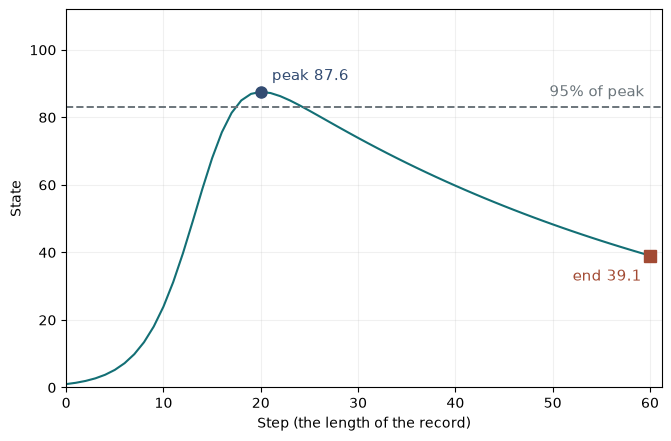

- **Peak:** 87.6
- **End of record:** 39.1
- **95% of peak:** 83.2
- **Last step change:** (-0.84)
- **Settles:** no
- **Peaks then falls:** yes

Threshold = 0.95 x 87.6 = 83.2. The record ends at 39.1, below it. Last step change = 39.06 - 39.90 = (-0.84). Peaks then falls: the end is more than 5% below the peak, so the record separates B from A.

In [10]:
show(window_reading(erosion=0.02, window=60))

**Use the idea.** Choose the window for a distinguishing observation from the time the mechanism needs to act, and write it beside the claim.

**Where the conclusion applies.** Rate 0.4, capacity 100 and a 5% margin. A different margin moves the window at which the fall is detected; a noisy real record would need a wider one.

*Constructed example: paths from the chapter's eroding_limit with erosion and window chosen for this reader.*

Every setting the interactive reader offers for this demonstration:

In [11]:
sweep(window_reading, [('erosion', [0.005, 0.02]), ('window', [30, 60, 100, 200])])

- **erosion = 0.005, window = 30**: Peak 95.5; End of record 93.0; 95% of peak 90.7; Last step change (-0.46); Settles no; Peaks then falls no
- **erosion = 0.005, window = 60**: Peak 95.5; End of record 79.9; 95% of peak 90.7; Last step change (-0.41); Settles no; Peaks then falls yes
- **erosion = 0.005, window = 100**: Peak 95.5; End of record 65.2; 95% of peak 90.7; Last step change (-0.33); Settles no; Peaks then falls yes
- **erosion = 0.005, window = 200**: Peak 95.5; End of record 39.3; 95% of peak 90.7; Last step change (-0.20); Settles no; Peaks then falls yes
- **erosion = 0.02, window = 30**: Peak 87.6; End of record 73.9; 95% of peak 83.2; Last step change (-1.58); Settles no; Peaks then falls yes
- **erosion = 0.02, window = 60**: Peak 87.6; End of record 39.1; 95% of peak 83.2; Last step change (-0.84); Settles no; Peaks then falls yes
- **erosion = 0.02, window = 100**: Peak 87.6; End of record 16.7; 95% of peak 83.2; Last step change (-0.36); Settles no; Peaks then falls yes
- **erosion = 0.02, window = 200**: Peak 87.6; End of record 2.0; 95% of peak 83.2; Last step change (-0.04); Settles no; Peaks then falls yes

## 4. One parameter turns B into A

*What happens to the eroding-limit model when the erosion rate is zero?*

With no erosion B's capacity stays at 100 and its update is the same as A's, so the paths coincide. Each positive erosion rate opens a gap that grows with the rate.



**Symbols and inputs.** erosion_rate is the capacity lost per unit of state per step. Everything else, the capacity of 100, the start of 1 and the growth rate, is shared by A and B.

**Predict first.** At erosion rate 0, how large is the largest gap between B and A?

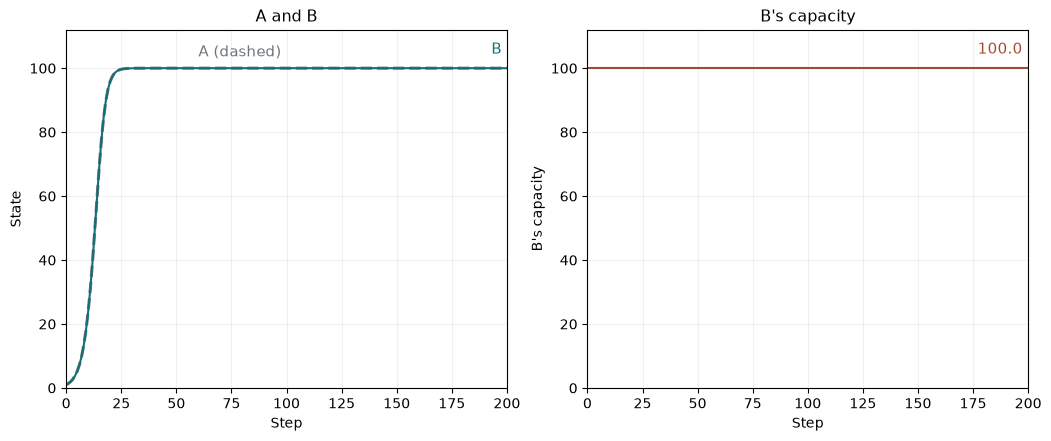

- **Erosion rate:** 0.000
- **Largest gap between B and A:** 0.00
- **B: value at the end:** 100.0
- **B: capacity at the end:** 100.0
- **Same path as A:** yes (tie)

After the first step the capacity is 100 - 0.000 x 1 = 100.000. Over 200 steps the largest gap between B and A is 0.00 units and B ends at 100.0 against A's 100.0. The two paths are the same, so B has become A.

In [12]:
show(zero_erosion(erosion_rate=0.0, rate=0.4))

**Use the idea.** When two accounts differ in outcome, find the single quantity whose value makes one reduce to the other; the archetype name rarely mentions it.

**Where the conclusion applies.** A 200 step horizon and a shared growth rate. The exact tie holds for this update rule only; a different erosion mechanism would need its own zero case.

*Constructed example: the chapter's zero-erosion test, run for several erosion rates chosen for this reader.*

Every setting the interactive reader offers for this demonstration:

In [13]:
sweep(zero_erosion, [('erosion_rate', [0.0, 0.005, 0.02, 0.04]), ('rate', [0.3, 0.4])])

- **erosion_rate = 0.0, rate = 0.3**: Erosion rate 0.000; Largest gap between B and A 0.00; B: value at the end 100.0; B: capacity at the end 100.0; Same path as A yes (tie)
- **erosion_rate = 0.0, rate = 0.4**: Erosion rate 0.000; Largest gap between B and A 0.00; B: value at the end 100.0; B: capacity at the end 100.0; Same path as A yes (tie)
- **erosion_rate = 0.005, rate = 0.3**: Erosion rate 0.005; Largest gap between B and A 59.96; B: value at the end 40.0; B: capacity at the end 39.4; Same path as A no
- **erosion_rate = 0.005, rate = 0.4**: Erosion rate 0.005; Largest gap between B and A 60.75; B: value at the end 39.3; B: capacity at the end 38.8; Same path as A no
- **erosion_rate = 0.02, rate = 0.3**: Erosion rate 0.020; Largest gap between B and A 97.95; B: value at the end 2.0; B: capacity at the end 1.9; Same path as A no
- **erosion_rate = 0.02, rate = 0.4**: Erosion rate 0.020; Largest gap between B and A 98.01; B: value at the end 2.0; B: capacity at the end 1.9; Same path as A no
- **erosion_rate = 0.04, rate = 0.3**: Erosion rate 0.040; Largest gap between B and A 99.98; B: value at the end 0.0; B: capacity at the end 0.0; Same path as A no
- **erosion_rate = 0.04, rate = 0.4**: Erosion rate 0.040; Largest gap between B and A 99.98; B: value at the end 0.0; B: capacity at the end 0.0; Same path as A no

## Exercises

Try each before opening the answer. The settings above let you check the numbers.

### Exercise 1

At 50% of capacity with rate 0.4, how many units does one step add?

<details><summary>Answer</summary>

0.4 x 50 x (1 - 50 / 100) = 10 units, half of the 20 an unconstrained step would add.

</details>

### Exercise 2

With rate 0.3 and 120 steps, what value does A end at?

<details><summary>Answer</summary>

A approaches its capacity of 100, so it ends at 100.0, matching the chapter's first printed result.

</details>

### Exercise 3

A peak of 87.6 and an end of 73.9: is the end below 95% of the peak?

<details><summary>Answer</summary>

0.95 x 87.6 = 83.2, and 73.9 is below 83.2, so the record shows peaks then falls.

</details>

---

From *Systems Thinking with AI* by Jason Karpeles. Copyright Jason Karpeles. All rights reserved.

Interactive companion: https://karpeles.com/companions/systems-thinking-with-ai/